# 4 · Housing segments (KMeans)
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/twillixa/california-housing-ml/blob/main/notebooks/04_clustering.ipynb)

The report clusters blocks on income, house value, housing age, rooms per household and people per household
(standardised), with k = 4, after a first attempt that included the coordinates (k = 6).

In [1]:
import sys, os
if "google.colab" in sys.modules:  # running on Colab: fetch the repo first
    !git clone -q https://github.com/twillixa/california-housing-ml
    %cd california-housing-ml/notebooks
sys.path.insert(0, os.path.abspath("../src"))

import warnings
os.environ["PYTHONWARNINGS"] = "ignore"  # parallel CV workers don't inherit warnings filters
warnings.filterwarnings("ignore", message=".*encountered in matmul")  # spurious on macOS Accelerate
warnings.filterwarnings("ignore", category=UserWarning)
import pandas as pd
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
from housing import plots
plots.use_style()
pd.set_option("display.precision", 4)
pd.set_option("display.width", 160)
from housing.data import clean
from housing import clustering as c
df = clean()

## The report's clusters

In [2]:
report_labels = c.kmeans(df, 4)
c.profile(df, report_labels).round(2)

,median_income,median_house_value,housing_median_age,rooms_per_household,population_per_household,blocks
cluster,,,,,,
2,5.62,309153.70,26.56,6.59,2.84,4931
3,6.67,185000.00,42.33,5.80,781.84,3
0,2.88,161961.41,38.85,4.66,3.11,7901
1,3.19,142031.71,17.51,5.29,2.93,6808


Identical to report Table 1, including **"cluster 3": 3 blocks averaging 782 people per household**. These are real
group-quarters blocks (prisons, dormitories, barracks) whose residents aren't counted as households, so the ratio
explodes. Because the ratio features were never capped, KMeans spends a whole cluster on them, and the report is left
with three usable segments.

In [3]:
df[["population_per_household", "rooms_per_household"]].describe(percentiles=[.01, .5, .99]).round(2)

,population_per_household,rooms_per_household
count,19643.00,19643.00
mean,3.10,5.36
std,10.64,2.29
min,0.69,0.85
1%,1.56,2.58
50%,2.84,5.19
99%,5.41,10.34
max,1243.33,132.53


## Clipping the ratios at their 1st / 99th percentiles

In [4]:
pd.DataFrame({"report": c.elbow(df), "clipped": c.elbow(df, clip_ratios=True)}).round(0)

,report,clipped
2,75396.0,71718.0
3,59313.0,60257.0
4,49227.0,50606.0
5,40414.0,45434.0
6,34864.0,41122.0
7,31616.0,38311.0
8,28783.0,35836.0
9,26263.0,33493.0
10,23881.0,31842.0


,segment,median_income,median_house_value,housing_median_age,rooms_per_household,population_per_household,blocks,inland share
cluster,,,,,,,,
0,Affluent newer suburbs,5.87,289278.37,22.59,7.04,3.11,4160,0.22
2,Established older neighbourhoods,3.49,234216.43,39.58,4.80,2.47,5142,0.13
3,Newer inland,3.10,134417.20,19.08,5.35,2.66,6123,0.59
1,Crowded lower-income,2.57,128218.47,33.88,4.41,4.47,4218,0.31


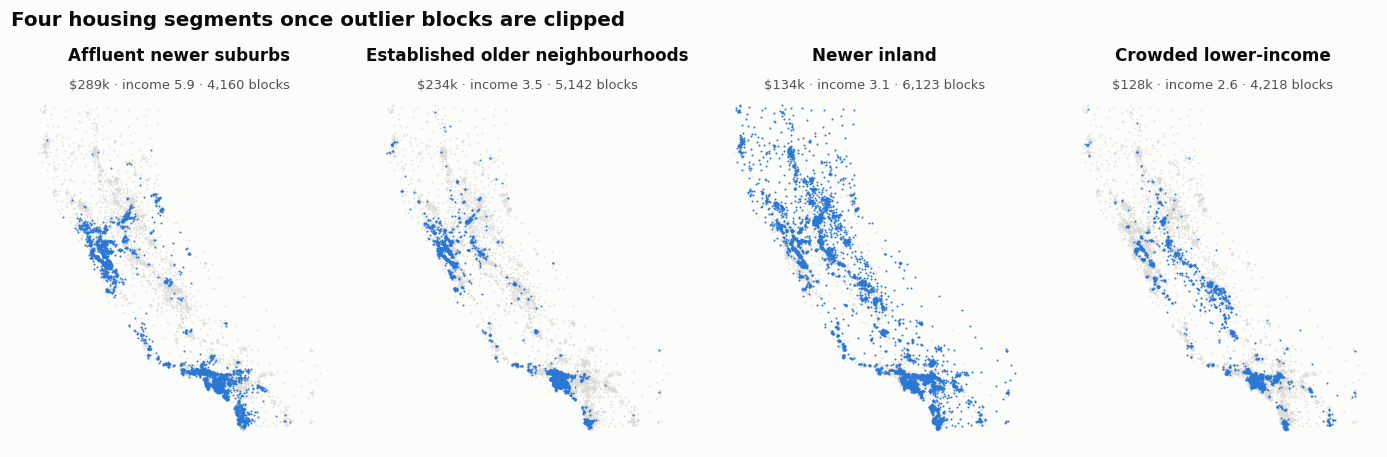

In [5]:
labels = c.kmeans(df, 4, clip_ratios=True)
profile = c.profile(df, labels)
names = dict(zip(profile.index, ["Affluent newer suburbs", "Established older neighbourhoods",
                                 "Newer inland", "Crowded lower-income"]))
profile.insert(0, "segment", profile.index.map(names))
inland = df.groupby(labels)["ocean_proximity"].apply(lambda s: (s == "INLAND").mean())
profile["inland share"] = inland
profile.round(2).to_csv("../reports/cluster_profiles.csv")
fig = plots.cluster_maps(df, labels, names); plots.save(fig, "clusters");
profile.round(2)

Four segments of about 4,200 to 6,100 blocks each:
- **Affluent newer suburbs**: highest income and value, larger homes.
- **Established older neighbourhoods**: older stock, many near the bay or ocean, mid-high values at mid income.
- **Newer inland**: recent construction, mostly inland, low values.
- **Crowded lower-income**: lowest income, about 4.5 people per household.

The k = 4 choice is still a judgement call: the elbow curve has no sharp bend in either version.